In [46]:
import pandas as pd
import numpy as np

from transformers import pipeline

from sklearn.feature_extraction.text import TfidfVectorizer

import nltk
from nltk.corpus import stopwords

import spacy

import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /Users/new/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [48]:
nlp = spacy.load("en_core_web_sm")

In [49]:
df = pd.read_csv("../data/raw/clean_reviews.csv")

In [50]:
df.head()

,review,rating,date,bank,source
0,IT'S NOT WORK ON HUAWEI DEVICES,4,2026-05-15,CBE,Google Play
1,wow,4,2026-05-14,CBE,Google Play
2,nice app,5,2026-05-14,CBE,Google Play
3,formative,5,2026-05-14,CBE,Google Play
4,best app for financial activities 🙌,5,2026-05-14,CBE,Google Play


In [51]:
df.shape

(1500, 5)

In [52]:
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

Device set to use cpu


In [53]:
def classify_sentiment(text):

    try:
        result = sentiment_pipeline(str(text))[0]

        label = result['label']
        score = result['score']

       
        if score < 0.60:
            sentiment = "neutral"

        elif label == "POSITIVE":
            sentiment = "positive"

        else:
            sentiment = "negative"

        return pd.Series([sentiment, score])

    except:
        return pd.Series(["neutral", 0.0])

In [54]:
df[['sentiment_label', 'sentiment_score']] = df['review'].apply(classify_sentiment)

In [55]:
df.head()

,review,rating,date,bank,source,sentiment_label,sentiment_score
0,IT'S NOT WORK ON HUAWEI DEVICES,4,2026-05-15,CBE,Google Play,negative,0.999691
1,wow,4,2026-05-14,CBE,Google Play,positive,0.999592
2,nice app,5,2026-05-14,CBE,Google Play,positive,0.999806
3,formative,5,2026-05-14,CBE,Google Play,positive,0.998885
4,best app for financial activities 🙌,5,2026-05-14,CBE,Google Play,positive,0.996808


In [56]:
df.tail()

,review,rating,date,bank,source,sentiment_label,sentiment_score
1495,good,5,2025-08-14,Dashen,Google Play,positive,0.999816
1496,There are plenty of features missed e. g elect...,2,2025-08-14,Dashen,Google Play,negative,0.999018
1497,የሶፍትዌሩ ለአጠቃቀም ምቹና ቀላል መሆኑ ተመራጭ ያደርገዋል,5,2025-08-14,Dashen,Google Play,negative,0.920041
1498,በጣም ችግር አለበት,1,2025-08-14,Dashen,Google Play,negative,0.833725
1499,best,5,2025-08-14,Dashen,Google Play,positive,0.999794


In [57]:
df['sentiment_label'].value_counts()

sentiment_label
positive    918
negative    573
neutral       9
Name: count, dtype: int64

In [58]:
df.groupby('bank')['sentiment_score'].mean()

bank
BOA       0.966775
CBE       0.977637
Dashen    0.975573
Name: sentiment_score, dtype: float64

In [59]:
df.groupby('rating')['sentiment_score'].mean()

rating
1    0.980421
2    0.964610
3    0.976991
4    0.963460
5    0.972233
Name: sentiment_score, dtype: float64

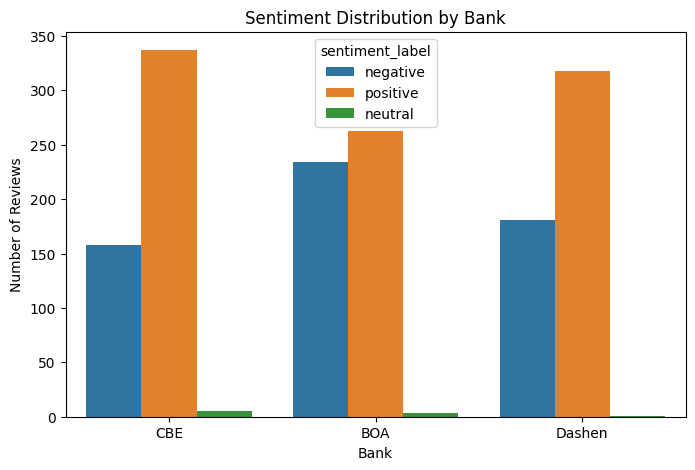

In [60]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='bank', hue='sentiment_label')

plt.title("Sentiment Distribution by Bank")
plt.xlabel("Bank")
plt.ylabel("Number of Reviews")

plt.show()

In [61]:
stop_words = set(stopwords.words('english'))

In [62]:
def preprocess_text(text):

    doc = nlp(str(text).lower())

    tokens = []

    for token in doc:

        if (
            token.text not in stop_words
            and token.is_alpha
        ):

            tokens.append(token.lemma_)

    return " ".join(tokens)

In [63]:
df['cleaned_review'] = df['review'].apply(preprocess_text)

In [64]:
df[['review', 'cleaned_review']].head()

,review,cleaned_review
0,IT'S NOT WORK ON HUAWEI DEVICES,work huawei device
1,wow,wow
2,nice app,nice app
3,formative,formative
4,best app for financial activities 🙌,good app financial activity


In [65]:
df[['review', 'cleaned_review']].tail()

,review,cleaned_review
1495,good,good
1496,There are plenty of features missed e. g elect...,plenty feature miss g electricity bill water b...
1497,የሶፍትዌሩ ለአጠቃቀም ምቹና ቀላል መሆኑ ተመራጭ ያደርገዋል,የሶፍትዌሩ ለአጠቃቀም ምቹና ቀላል መሆኑ ተመራጭ ያደርገዋል
1498,በጣም ችግር አለበት,በጣም ችግር አለበት
1499,best,good


In [66]:
vectorizer = TfidfVectorizer(
    max_features=20,
    ngram_range=(1,2)
)

X = vectorizer.fit_transform(df['cleaned_review'])

In [67]:
keywords = vectorizer.get_feature_names_out()

keywords

array(['app', 'bad', 'bank', 'banking', 'dashen', 'easy', 'even', 'fast',
       'fix', 'good', 'good app', 'like', 'mobile', 'nice', 'please',
       'service', 'time', 'update', 'use', 'work'], dtype=object)

In [68]:
tfidf_scores = X.sum(axis=0).A1

keyword_df = pd.DataFrame({
    'keyword': keywords,
    'score': tfidf_scores
})

keyword_df = keyword_df.sort_values(
    by='score',
    ascending=False
)

keyword_df.head(20)

,keyword,score
9,good,323.664861
0,app,260.445614
13,nice,87.069005
19,work,81.933760
2,bank,79.967395
18,use,64.910990
10,good app,49.579759
17,update,45.349137
1,bad,44.675740
7,fast,38.836838


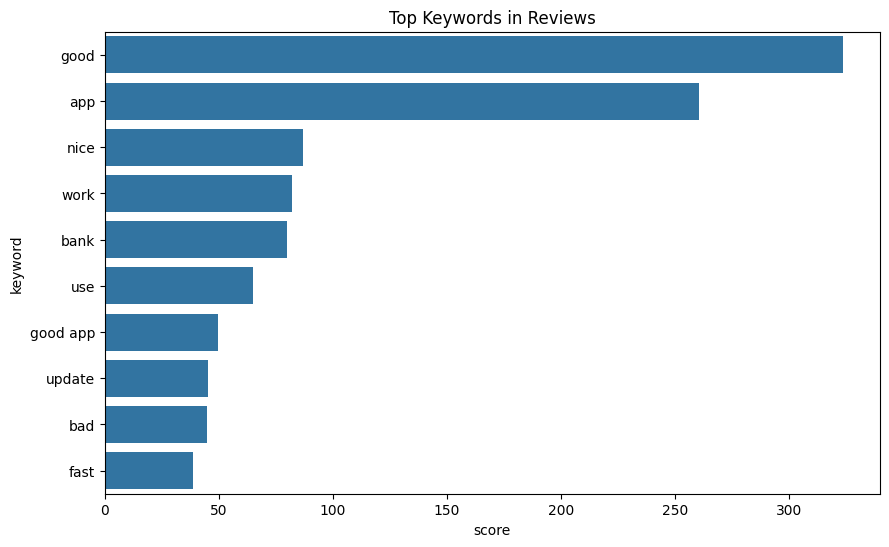

In [69]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=keyword_df.head(10),
    x='score',
    y='keyword'
)

plt.title("Top Keywords in Reviews")

plt.show()

In [70]:
def identify_theme(text):

    if pd.isnull(text):
        return "General Experience"

    text = text.lower()

    if (
        "login" in text
        or "log in" in text
        or "otp" in text
        or "password" in text
        or "access" in text
        or "verification" in text
        or "sign in" in text
        or "authenticate" in text
    ):
        return "Account Access Issues"

    elif (
        "transfer" in text
        or "transaction" in text
        or "slow" in text
        or "loading" in text
        or "payment" in text
        or "sending" in text
        or "failed" in text
        or "processing" in text
        or "delay" in text
    ):
        return "Transaction Performance"

    elif (
        "ui" in text
        or "design" in text
        or "interface" in text
        or "layout" in text
        or "navigation" in text
        or "appearance" in text
    ):
        return "UI & Design"

   
    elif (
        "support" in text
        or "help" in text
        or "customer care" in text
        or "service" in text
        or "response" in text
    ):
        return "Customer Support"

   
    elif (
        "feature" in text
        or "update" in text
        or "fingerprint" in text
        or "dark mode" in text
        or "improve" in text
        or "add" in text
    ):
        return "Feature Requests"


    else:
        return "General Experience"

In [71]:
df['identified_theme'] = df['cleaned_review'].apply(identify_theme)

In [72]:
df['identified_theme'].value_counts()

identified_theme
General Experience         1217
Transaction Performance     100
Feature Requests             64
Customer Support             47
Account Access Issues        47
UI & Design                  25
Name: count, dtype: int64

In [73]:
pd.crosstab(df['bank'], df['identified_theme'])

identified_theme,Account Access Issues,Customer Support,Feature Requests,General Experience,Transaction Performance,UI & Design
bank,,,,,,
BOA,19,13,16,418,29,5
CBE,9,20,23,410,33,5
Dashen,19,14,25,389,38,15


In [74]:
final_df = pd.DataFrame({
    'review_id': df.index,
    'review_text': df['review'],
    'sentiment_label': df['sentiment_label'],
    'sentiment_score': df['sentiment_score'],
    'identified_theme': df['identified_theme']
})

In [89]:
final_df.to_csv(
    "../data/raw/task2_processed_reviews.csv",
    index=False
)

In [94]:
df.to_csv("../data/raw/final_processed_reviews.csv", index=False)

In [95]:
df.head()

,review,rating,date,bank,source,sentiment_label,sentiment_score,cleaned_review,identified_theme
0,IT'S NOT WORK ON HUAWEI DEVICES,4,2026-05-15,CBE,Google Play,negative,0.999691,work huawei device,General Experience
1,wow,4,2026-05-14,CBE,Google Play,positive,0.999592,wow,General Experience
2,nice app,5,2026-05-14,CBE,Google Play,positive,0.999806,nice app,General Experience
3,formative,5,2026-05-14,CBE,Google Play,positive,0.998885,formative,General Experience
4,best app for financial activities 🙌,5,2026-05-14,CBE,Google Play,positive,0.996808,good app financial activity,General Experience


In [96]:
final_df.head()

,review_id,review_text,sentiment_label,sentiment_score,identified_theme
0,0,IT'S NOT WORK ON HUAWEI DEVICES,negative,0.999691,General Experience
1,1,wow,positive,0.999592,General Experience
2,2,nice app,positive,0.999806,General Experience
3,3,formative,positive,0.998885,General Experience
4,4,best app for financial activities 🙌,positive,0.996808,General Experience
